In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Cari folder output yang berisi hasil Tahap 1 ─────────────
OUTPUT_DIR = None
for kandidat in ['output', '../output']:
    if os.path.exists(os.path.join(kandidat, 'tahap1_data.pkl')):
        OUTPUT_DIR = kandidat
        break
if OUTPUT_DIR is None:
    raise FileNotFoundError(
        'File tahap1_data.pkl tidak ditemukan di "output/" maupun "../output/". '
        'Jalankan notebook Tahap 1 sampai sel terakhir (Simpan Data) terlebih dulu.'
    )

with open(os.path.join(OUTPUT_DIR, 'tahap1_data.pkl'), 'rb') as f:
    d = pickle.load(f)

X_linear    = d['X_linear']
X_poly      = d['X_poly']
meta_linear = d['meta_linear']
meta_poly   = d['meta_poly']

assert X_linear.shape[0] > 1 and X_poly.shape[0] > 1, 'Data Tahap 1 kosong, ulangi Tahap 1.'
assert X_linear.select_dtypes('number').shape[1] == X_linear.shape[1], 'Data Tahap 1 tidak numerik.'

N_SAMPEL = X_poly.shape[0]
print(f'Data Tahap 1 dimuat dari: {os.path.abspath(OUTPUT_DIR)}')
print(f'  X_linear : {X_linear.shape}')
print(f'  X_poly   : {X_poly.shape}')

Data Tahap 1 dimuat dari: C:\Users\OKAN\OneDrive\Dokumen\PSD\materi\Clustering_Segmentasi\output
  X_linear : (37, 204)
  X_poly   : (37, 204)


Setelah StandardScaler:
  Linear — shape: (37, 204), mean: 0.000000, std: 0.985184
  Poly   — shape: (37, 204), mean: 0.000000, std: 0.987669


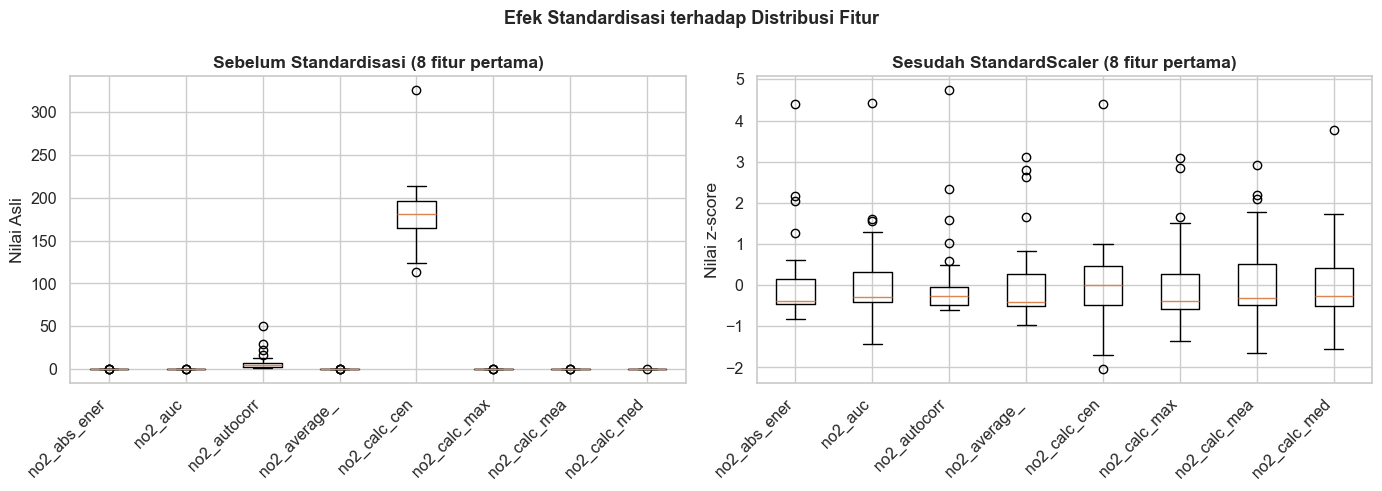

In [2]:
scaler_lin  = StandardScaler()
scaler_poly = StandardScaler()

Xs_linear = scaler_lin.fit_transform(X_linear)
Xs_poly   = scaler_poly.fit_transform(X_poly)

print('Setelah StandardScaler:')
print(f'  Linear — shape: {Xs_linear.shape}, mean: {Xs_linear.mean():.6f}, std: {Xs_linear.std():.6f}')
print(f'  Poly   — shape: {Xs_poly.shape}, mean: {Xs_poly.mean():.6f}, std: {Xs_poly.std():.6f}')

# Sebelum vs sesudah (8 fitur pertama)
n_viz    = min(8, X_poly.shape[1])
cols_viz = list(X_poly.columns[:n_viz])
lbl      = [c[:12] for c in cols_viz]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot([X_poly[c].values for c in cols_viz])
axes[0].set_xticklabels(lbl, rotation=45, ha='right')
axes[0].set_title(f'Sebelum Standardisasi ({n_viz} fitur pertama)', fontweight='bold')
axes[0].set_ylabel('Nilai Asli')

axes[1].boxplot([Xs_poly[:, i] for i in range(n_viz)])
axes[1].set_xticklabels(lbl, rotation=45, ha='right')
axes[1].set_title(f'Sesudah StandardScaler ({n_viz} fitur pertama)', fontweight='bold')
axes[1].set_ylabel('Nilai z-score')

plt.suptitle('Efek Standardisasi terhadap Distribusi Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_standardisasi.png', dpi=150, bbox_inches='tight')
plt.show()

Linear     : 37 sampel x 204 fitur -> PCA maks 37 komponen, variansi 99% dicapai di PC-26, komponen terakhir = 1.90e-33
Polynomial : 37 sampel x 204 fitur -> PCA maks 37 komponen, variansi 99% dicapai di PC-27, komponen terakhir = 6.16e-32


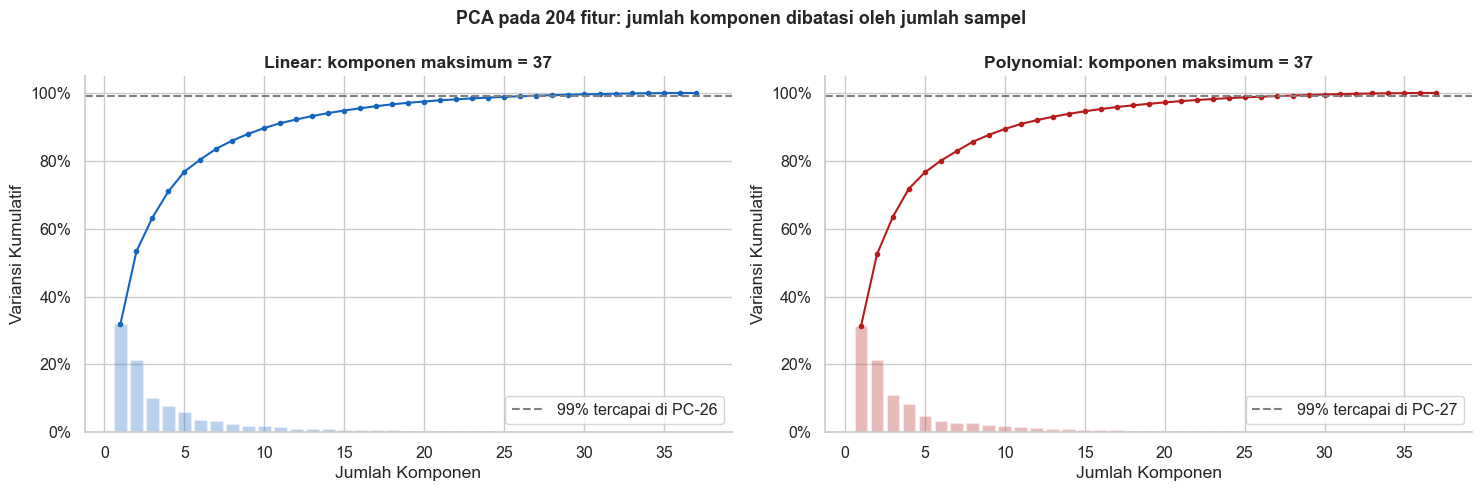


PCA(203) -> ValueError: n_components=203 must be between 0 and min(n_samples, n_features)=37 with svd_solver='full'...

PCA(74) -> ValueError: n_components=74 must be between 0 and min(n_samples, n_features)=37 with svd_solver='full'...


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, Xs, nama, color in [(axes[0], Xs_linear, 'Linear', '#1565C0'),
                            (axes[1], Xs_poly,   'Polynomial', '#B71C1C')]:
    p_full = PCA(random_state=42).fit(Xs)          # semua komponen yang mungkin
    cum    = np.cumsum(p_full.explained_variance_ratio_)
    k      = np.arange(1, len(cum) + 1)
    n_99   = int(np.argmax(cum >= 0.99) + 1)

    ax.bar(k, p_full.explained_variance_ratio_, color=color, alpha=0.3)
    ax.plot(k, cum, 'o-', color=color, markersize=3)
    ax.axhline(0.99, color='gray', linestyle='--', label=f'99% tercapai di PC-{n_99}')
    ax.set_title(f'{nama}: komponen maksimum = {p_full.n_components_}', fontweight='bold')
    ax.set_xlabel('Jumlah Komponen'); ax.set_ylabel('Variansi Kumulatif')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(); ax.spines[['top', 'right']].set_visible(False)

    print(f'{nama:<11}: {Xs.shape[0]} sampel x {Xs.shape[1]} fitur -> PCA maks {p_full.n_components_} komponen, '
          f'variansi 99% dicapai di PC-{n_99}, komponen terakhir = {p_full.explained_variance_ratio_[-1]:.2e}')

plt.suptitle('PCA pada 204 fitur: jumlah komponen dibatasi oleh jumlah sampel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04a_batas_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# Bukti: PCA 203 / 74 komponen tidak mungkin
for k in (203, 74):
    try:
        PCA(n_components=k).fit(Xs_poly)
    except ValueError as e:
        print(f'\nPCA({k}) -> ValueError: {str(e)[:110]}...')

In [4]:
def kurangi_fitur(X_df, target, nama=''):
    """
    Seleksi fitur berbasis korelasi: membuang fitur paling redundan sampai tersisa `target` fitur.

    1. Fitur konstan (std = 0) dibuang lebih dulu.
    2. Selama fitur > target: cari pasangan fitur dengan |korelasi| tertinggi, lalu buang
       salah satunya, yaitu yang rata-rata |korelasi|-nya terhadap fitur lain lebih besar.

    Returns
    -------
    list nama fitur yang dipertahankan, list nama fitur yang dibuang
    """
    kolom   = list(X_df.columns)
    dibuang = []

    # 1) fitur konstan
    konstan = [c for c in kolom if X_df[c].std() == 0 or np.isnan(X_df[c].std())]
    for c in konstan[: max(0, len(kolom) - target)]:
        dibuang.append(c)
    sisa = [c for c in kolom if c not in dibuang]

    # 2) pangkas yang paling redundan
    C = np.array(X_df[sisa].corr().abs().fillna(0), dtype=float)   # salinan yang bisa diubah
    np.fill_diagonal(C, 0.0)
    aktif = np.ones(len(sisa), dtype=bool)

    while aktif.sum() > target:
        idx = np.where(aktif)[0]
        sub = C[np.ix_(idx, idx)]
        i, j = np.unravel_index(np.argmax(sub), sub.shape)
        gi, gj = idx[i], idx[j]
        rata_i = C[gi, idx].mean()
        rata_j = C[gj, idx].mean()
        hapus = gi if rata_i >= rata_j else gj
        aktif[hapus] = False
        dibuang.append(sisa[hapus])

    dipertahankan = [c for c, a in zip(sisa, aktif) if a]
    assert len(dipertahankan) == target, f'{nama}: hasil {len(dipertahankan)} != target {target}'
    return dipertahankan, dibuang


def rata_korelasi(X_df):
    """Rata-rata |korelasi| antar fitur (semakin kecil = semakin sedikit redundansi)."""
    C = np.array(X_df.corr().abs().fillna(0), dtype=float)
    n = C.shape[0]
    return (C.sum() - n) / (n * (n - 1))


def jalankan_pca(X_scaled, n_comp, nama):
    pca    = PCA(n_components=n_comp, random_state=42)
    X_pca  = pca.fit_transform(X_scaled)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    print(f'[{nama}] {X_scaled.shape[1]} dimensi -> {n_comp} komponen')
    print(f'  Variansi PC-10 : {cumvar[min(9, n_comp-1)]:.2%}')
    print(f'  Variansi PC-{n_comp} : {cumvar[-1]:.2%}')
    return pca, X_pca, cumvar

print('Fungsi kurangi_fitur(), rata_korelasi(), jalankan_pca() siap digunakan.')

Fungsi kurangi_fitur(), rata_korelasi(), jalankan_pca() siap digunakan.


In [5]:
print('=== TAHAP 1: 204 -> 203 ===\n')
feat203_lin,  drop1_lin  = kurangi_fitur(X_linear, 203, 'Linear')
feat203_poly, drop1_poly = kurangi_fitur(X_poly,   203, 'Poly')

print(f'Linear : {X_linear.shape[1]} -> {len(feat203_lin)} fitur, dibuang: {drop1_lin}')
print(f'Poly   : {X_poly.shape[1]} -> {len(feat203_poly)} fitur, dibuang: {drop1_poly}')

X_lin203_df  = X_linear[feat203_lin]
X_poly203_df = X_poly[feat203_poly]

=== TAHAP 1: 204 -> 203 ===

Linear : 204 -> 203 fitur, dibuang: ['no2_human_range_energy']
Poly   : 204 -> 203 fitur, dibuang: ['no2_human_range_energy']


=== TAHAP 2: 203 -> 74 ===

Linear : 203 -> 74 fitur (129 dibuang)
Poly   : 203 -> 74 fitur (129 dibuang)

Rata-rata |korelasi| antar fitur:
  Linear : 0.306 (203 fitur) -> 0.240 (74 fitur)
  Poly   : 0.304 (203 fitur) -> 0.245 (74 fitur)


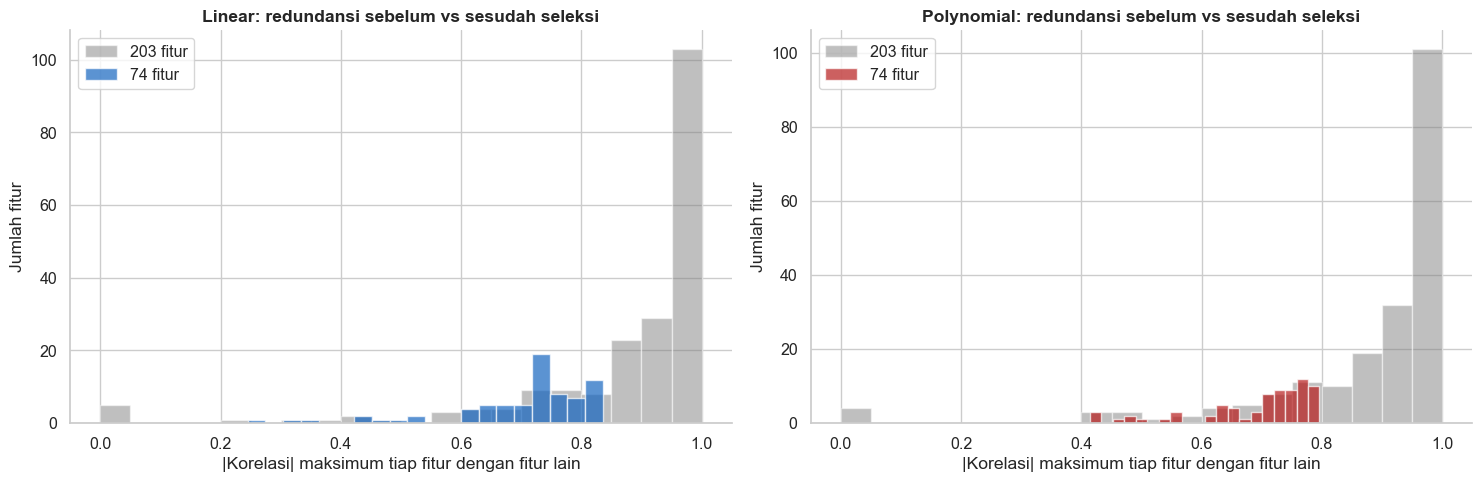

In [6]:
print('=== TAHAP 2: 203 -> 74 ===\n')
feat74_lin,  drop2_lin  = kurangi_fitur(X_lin203_df,  74, 'Linear')
feat74_poly, drop2_poly = kurangi_fitur(X_poly203_df, 74, 'Poly')

X_lin74_df  = X_linear[feat74_lin]
X_poly74_df = X_poly[feat74_poly]

print(f'Linear : 203 -> {len(feat74_lin)} fitur ({len(drop2_lin)} dibuang)')
print(f'Poly   : 203 -> {len(feat74_poly)} fitur ({len(drop2_poly)} dibuang)')

# Tingkat redundansi sebelum vs sesudah
r_before_l, r_after_l = rata_korelasi(X_lin203_df),  rata_korelasi(X_lin74_df)
r_before_p, r_after_p = rata_korelasi(X_poly203_df), rata_korelasi(X_poly74_df)
print(f'\nRata-rata |korelasi| antar fitur:')
print(f'  Linear : {r_before_l:.3f} (203 fitur) -> {r_after_l:.3f} (74 fitur)')
print(f'  Poly   : {r_before_p:.3f} (203 fitur) -> {r_after_p:.3f} (74 fitur)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, a, b, nama, color in [(axes[0], X_lin203_df,  X_lin74_df,  'Linear',     '#1565C0'),
                              (axes[1], X_poly203_df, X_poly74_df, 'Polynomial', '#B71C1C')]:
    def max_corr(df):
        C = np.array(df.corr().abs().fillna(0), dtype=float); np.fill_diagonal(C, 0)
        return C.max(axis=1)
    ax.hist(max_corr(a), bins=20, alpha=0.5, color='gray', label='203 fitur')
    ax.hist(max_corr(b), bins=20, alpha=0.7, color=color, label='74 fitur')
    ax.set_xlabel('|Korelasi| maksimum tiap fitur dengan fitur lain')
    ax.set_ylabel('Jumlah fitur')
    ax.set_title(f'{nama}: redundansi sebelum vs sesudah seleksi', fontweight='bold')
    ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_seleksi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
Xs_lin74  = StandardScaler().fit_transform(X_lin74_df)
Xs_poly74 = StandardScaler().fit_transform(X_poly74_df)

print('=== TAHAP 3: 74 -> 37 (PCA) ===\n')
pca_lin,  X_lin37,  cv_lin  = jalankan_pca(Xs_lin74,  37, 'Linear')
print()
pca_poly, X_poly37, cv_poly = jalankan_pca(Xs_poly74, 37, 'Poly')

=== TAHAP 3: 74 -> 37 (PCA) ===

[Linear] 74 dimensi -> 37 komponen
  Variansi PC-10 : 81.15%
  Variansi PC-37 : 100.00%

[Poly] 74 dimensi -> 37 komponen
  Variansi PC-10 : 81.81%
  Variansi PC-37 : 100.00%


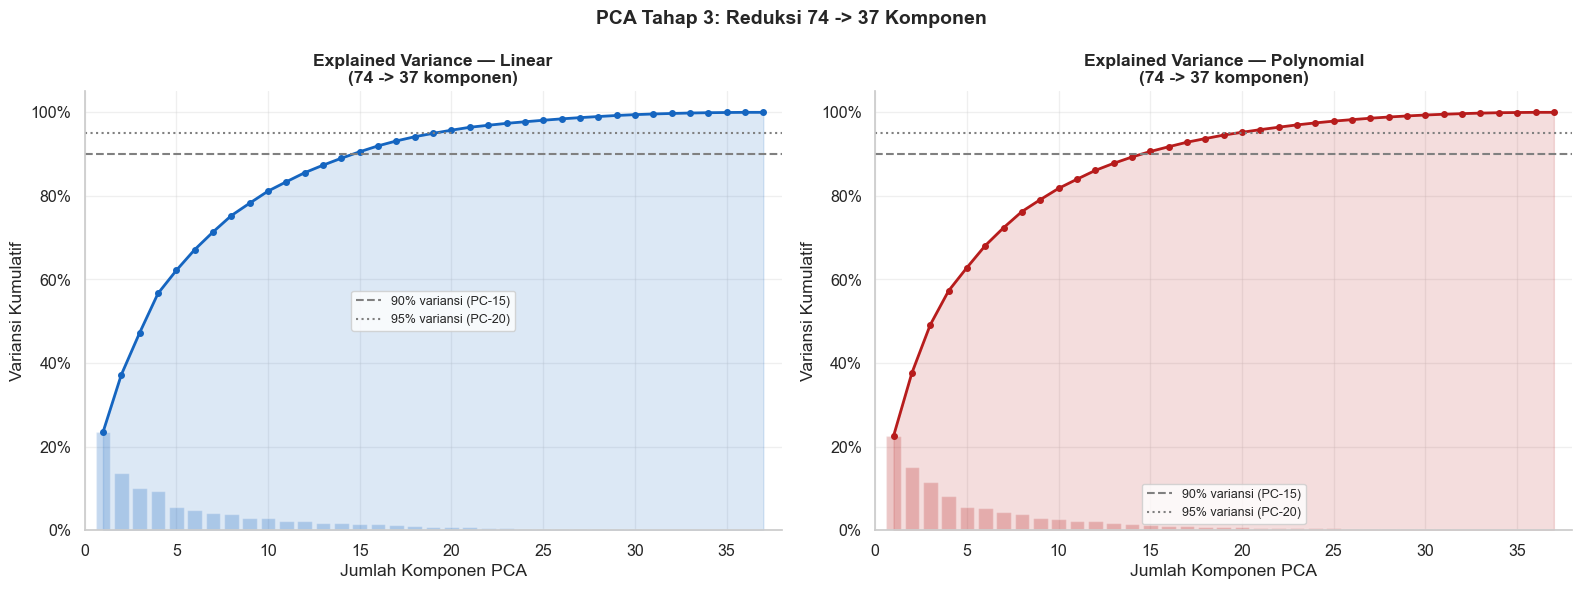

Gambar disimpan: output/06_pca_tahap3.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pcs = np.arange(1, 38)

for ax, cumvar, pca_obj, nama, color in [
    (axes[0], cv_lin,  pca_lin,  'Linear',     '#1565C0'),
    (axes[1], cv_poly, pca_poly, 'Polynomial', '#B71C1C')]:
    ax.fill_between(pcs, cumvar, alpha=0.15, color=color)
    ax.plot(pcs, cumvar, 'o-', color=color, linewidth=2, markersize=4)
    ax.bar(pcs, pca_obj.explained_variance_ratio_, alpha=0.25, color=color, width=0.8)
    for thresh, ls in [(0.90, '--'), (0.95, ':')]:
        n_t = int(np.argmax(cumvar >= thresh) + 1)
        ax.axhline(thresh, color='gray', linestyle=ls, linewidth=1.5, label=f'{thresh:.0%} variansi (PC-{n_t})')
    ax.set_xlim(0, 38); ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_xlabel('Jumlah Komponen PCA'); ax.set_ylabel('Variansi Kumulatif')
    ax.set_title(f'Explained Variance — {nama}\n(74 -> 37 komponen)', fontweight='bold')
    ax.legend(fontsize=9); ax.spines[['top', 'right']].set_visible(False); ax.grid(True, alpha=0.3)

plt.suptitle('PCA Tahap 3: Reduksi 74 -> 37 Komponen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_pca_tahap3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: output/06_pca_tahap3.png')

In [9]:
representasi = {
    'Linear-204' : Xs_linear,
    'Linear-203' : StandardScaler().fit_transform(X_lin203_df),
    'Linear-74'  : Xs_lin74,
    'Linear-37'  : X_lin37,
    'Poly-204'   : Xs_poly,
    'Poly-203'   : StandardScaler().fit_transform(X_poly203_df),
    'Poly-74'    : Xs_poly74,
    'Poly-37'    : X_poly37,
}

print(f'{"Nama":<12} {"Bentuk":<12} Keterangan')
print('-' * 62)
ket = {'204': 'fitur asli', '203': 'seleksi fitur 1', '74': 'seleksi fitur 2', '37': 'PCA (variansi 74 fitur: '}
for nama, X in representasi.items():
    dim = nama.split('-')[1]
    extra = ket[dim]
    if dim == '37':
        extra += f"{(cv_lin if nama.startswith('Linear') else cv_poly)[-1]:.1%})"
    print(f'{nama:<12} {str(X.shape):<12} {extra}')

assert all(X.shape[0] == N_SAMPEL and not np.isnan(X).any() for X in representasi.values())
print('\nSemua 8 representasi valid (tanpa NaN) dan siap untuk eksperimen clustering.')

Nama         Bentuk       Keterangan
--------------------------------------------------------------
Linear-204   (37, 204)    fitur asli
Linear-203   (37, 203)    seleksi fitur 1
Linear-74    (37, 74)     seleksi fitur 2
Linear-37    (37, 37)     PCA (variansi 74 fitur: 100.0%)
Poly-204     (37, 204)    fitur asli
Poly-203     (37, 203)    seleksi fitur 1
Poly-74      (37, 74)     seleksi fitur 2
Poly-37      (37, 37)     PCA (variansi 74 fitur: 100.0%)

Semua 8 representasi valid (tanpa NaN) dan siap untuk eksperimen clustering.


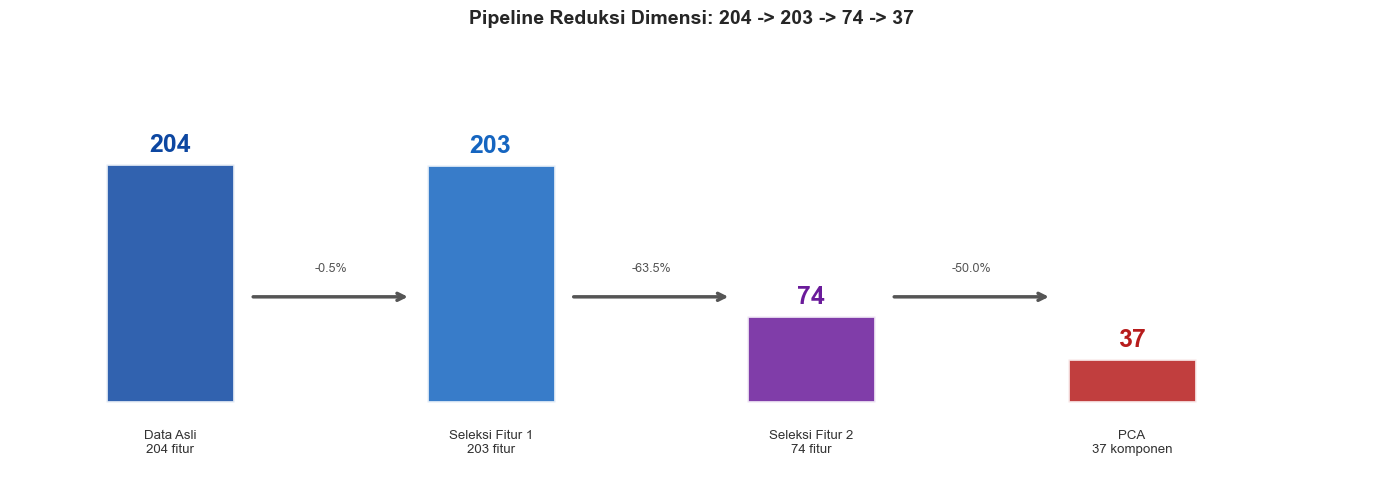

Gambar disimpan: output/04c_pipeline_reduksi.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
tahapan = [('Data Asli\n204 fitur', 204, '#0D47A1'),
           ('Seleksi Fitur 1\n203 fitur', 203, '#1565C0'),
           ('Seleksi Fitur 2\n74 fitur', 74, '#6A1B9A'),
           ('PCA\n37 komponen', 37, '#B71C1C')]
x_pos, max_dim = [1, 3, 5, 7], 210

for i, ((label, dim, color), x) in enumerate(zip(tahapan, x_pos)):
    height = (dim / max_dim) * 3.5
    ax.add_patch(plt.Rectangle((x - 0.4, 0.5), 0.8, height, facecolor=color, alpha=0.85, edgecolor='white', linewidth=2))
    ax.text(x, height + 0.6, f'{dim}', ha='center', va='bottom', fontsize=18, fontweight='bold', color=color)
    ax.text(x, 0.1, label, ha='center', va='top', fontsize=9.5, color='#333', multialignment='center')
    if i < len(tahapan) - 1:
        ax.annotate('', xy=(x_pos[i+1] - 0.5, 2.0), xytext=(x + 0.5, 2.0),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=2.5))
        pct = (1 - tahapan[i+1][1] / dim) * 100
        ax.text((x + x_pos[i+1]) / 2, 2.35, f'-{pct:.1f}%', ha='center', fontsize=9, color='#555')

ax.set_xlim(0, 8.5); ax.set_ylim(-0.5, 5.5); ax.axis('off')
ax.set_title('Pipeline Reduksi Dimensi: 204 -> 203 -> 74 -> 37', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04c_pipeline_reduksi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: output/04c_pipeline_reduksi.png')

In [11]:
save_data = {
    'representasi': representasi,
    'meta_linear' : meta_linear,
    'meta_poly'   : meta_poly,
    'X_linear'    : X_linear,
    'X_poly'      : X_poly,
    # fitur yang dipertahankan di tiap tahap seleksi
    'feat203_lin' : feat203_lin,  'feat203_poly': feat203_poly,
    'feat74_lin'  : feat74_lin,   'feat74_poly' : feat74_poly,
    # variansi PCA tahap akhir (74 -> 37)
    'cv_lin'      : cv_lin,
    'cv_poly'     : cv_poly,
}
save_path = os.path.join(OUTPUT_DIR, 'tahap2_pca.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f'Hasil disimpan : {os.path.abspath(save_path)}')
print(f'Ukuran file    : {os.path.getsize(save_path)/1024:.1f} KB')
print(f'Jumlah representasi: {len(representasi)}')
print('\n→ Lanjut ke Tahap 3: Eksperimen Clustering & Silhouette Analysis')

Hasil disimpan : C:\Users\OKAN\OneDrive\Dokumen\PSD\materi\Clustering_Segmentasi\output\tahap2_pca.pkl
Ukuran file    : 434.3 KB
Jumlah representasi: 8

→ Lanjut ke Tahap 3: Eksperimen Clustering & Silhouette Analysis
